# Лабораторная работа 4.

In [7]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv('SMS.tsv', sep='\t')
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.describe()

,class,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [4]:
df.isnull().sum()

class    0
text     0
dtype: int64

Всего объектов: 5572
Ham (0): 4825
Spam (1): 747
Доля спама: 13.41%


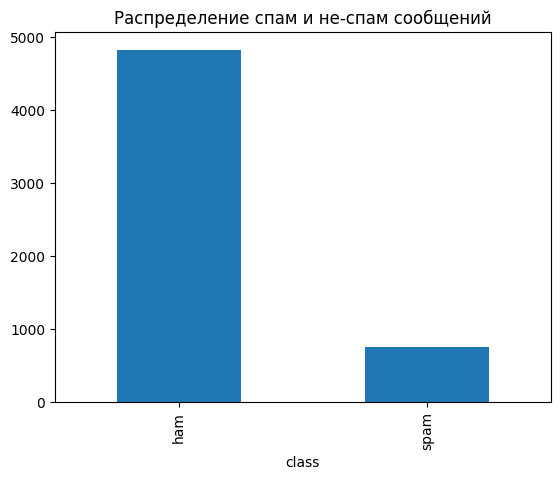

In [13]:
df['class'].value_counts().plot(kind='bar')
plt.title('Распределение спам и не-спам сообщений')

y = df['class'].map({'ham': 0, 'spam': 1}).values
print(f"Всего объектов: {len(y)}")
print(f"Ham (0): {np.sum(y == 0)}")
print(f"Spam (1): {np.sum(y == 1)}")
print(f"Доля спама: {np.mean(y):.2%}")

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english', lowercase=True)
X = vectorizer.fit_transform(df['text'])

feature_names = vectorizer.get_feature_names_out()

In [11]:
print(f"Размерность матрицы признаков: [{X.shape[0]}; {X.shape[1]}]")
print(f"Количество признаков (слов): {len(feature_names)}")

Размерность матрицы признаков: [5572; 8444]
Количество признаков (слов): 8444


In [38]:
print(feature_names[2025:2100])

['classmates' 'claypot' 'cld' 'clean' 'cleaning' 'clear' 'cleared'
 'clearer' 'clearing' 'clearly' 'clever' 'click' 'cliff' 'cliffs' 'clip'
 'clock' 'clocks' 'clos1' 'close' 'closeby' 'closed' 'closer' 'closes'
 'closingdate04' 'cloth' 'clothes' 'cloud' 'clover' 'club' 'club4'
 'club4mobiles' 'clubmoby' 'clubsaisai' 'clubzed' 'clue' 'cm' 'cm2' 'cme'
 'cmon' 'cn' 'cnl' 'cnn' 'cnupdates' 'coach' 'coast' 'coat' 'coaxing'
 'coca' 'coccooning' 'cochin' 'cock' 'cocksuckers' 'coco' 'code' 'coffee'
 'coherently' 'coimbatore' 'coin' 'coincidence' 'coins' 'cola' 'colany'
 'cold' 'colin' 'collages' 'collapsed' 'colleagues' 'collect' 'collected'
 'collecting' 'collection' 'colleg' 'college' 'color' 'colour']


Делим данные на тренировочную и тестовую выборки со стратификацией.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1633, stratify=y)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (4457, 8444)
Тестовая выборка: (1115, 8444)


In [50]:
def return_results(percent, scores, names):
    k = np.ceil(len(names) * percent / 100).astype(int)
    selected_indices = np.argsort(scores)[-k:][::-1]
    selected_names = [names[i] for i in selected_indices]
    
    return selected_indices, selected_names, scores

#### Фильтрующий метод

Рукописный хи-квадрат:

In [ ]:
import numpy as np

def chi2_selector(X, y, names, percent=70):
    X = X.toarray()
    count_sms, count_f = X.shape
    chi2_scores = np.zeros(count_f)
    
    for i in range(count_f):
        val = X[:, i] > 0
        not_val = X[:, i] == 0
        
        a = np.sum(val & (y == 1))
        b = np.sum(val & (y == 0))
        c = np.sum(not_val & (y == 1))
        d = np.sum(not_val & (y == 0))
        
        value = (a + b) * (c + d) * (a + c) * (b + d)
        if value == 0:
            value = 1e-10

        chi2_scores[i] = (count_sms * (a * d - b * c)**2) / value

    return return_results(percent, chi2_scores, names)

selected_indices_chi2, selected_names_chi2, chi2_scores = chi2_selector(X_train, y_train, feature_names)
chi2_result = selected_names_chi2[:30]
print(f"Оставлено признаков: {len(selected_indices_chi2)}")
print(f"Лучшие признаки (с наибольшими значениями хи-квадрат): {chi2_result}")

Оставлено признаков: 5911
Лучшие признаки (с наибольшими значениями хи-квадрат): ['txt', 'free', 'claim', 'www', 'mobile', 'prize', 'stop', '150p', 'uk', 'won', 'cash', 'guaranteed', 'urgent', '16', 'reply', 'text', 'win', '18', '50', 'service', 'nokia', 'contact', '500', '1000', 'cs', 'com', 'tone', '100', 'awarded', '150ppm']


Стат.тест ANOVA (из sklearn)

In [124]:
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

def anova_selector(X, y, feature_names, percent=70):
    k = np.ceil(X.shape[1] * percent / 100).astype(int)
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    f_scores, p_values = f_classif(X, y)
    sorted_idx = np.argsort(p_values)
    selected_indices = sorted_idx[:k]
    selected_names = np.array(feature_names)[selected_indices]
    
    return selected_indices, selected_names, selector.scores_

selected_indices_anova, selected_names_anova, anova_scores = anova_selector(X_train, y_train, feature_names)
anova_result = selected_names_anova[:30]
print(f"Оставлено признаков: {len(selected_indices_anova)}")
print(f"Лучшие признаки (отсортированы по p-value): {anova_result}")

Оставлено признаков: 5911
Лучшие признаки (отсортированы по p-value): ['txt' 'free' 'claim' 'www' 'mobile' 'prize' 'stop' '150p' 'won' 'uk'
 'guaranteed' 'urgent' '16' 'text' 'reply' 'cash' '18' '50' 'service'
 'win' 'contact' '500' '1000' 'cs' 'nokia' 'com' '100' 'awarded' '150ppm'
 'customer']


#### Встроенный метод

Рукописный градиентный спуск с l1 + l2 регуляризацией

In [80]:
def gd(X, y, start=np.zeros(X.shape[1]), alpha=0, pho=1, 
                learning_rate=(lambda x: 0.1), iter=1000):

    m = X.shape[0]
    theta = start
    loss_history = []
    
    for step in range(iter):
        z = X.dot(theta)
        predictions = 1 / (1 + np.exp(-z))
        loss = -np.mean(y * np.log(predictions + 1e-15) + 
                       (1 - y) * np.log(1 - predictions + 1e-15))
        loss_history.append(loss)
        grad_theta = X.T.dot(predictions - y) / m
        l1_grad = alpha * pho * np.sign(theta)
        l2_grad = alpha * (1 - pho) * theta
        
        new_theta = theta - learning_rate(step) * (grad_theta + l1_grad + l2_grad)
        theta = new_theta
    
    def predict(X_test):
        z = X_test.dot(theta)
        proba = 1 / (1 + np.exp(-z))
        return np.where(proba >= 0.5, 1, 0)
    
    return theta, loss_history, predict

t, loss_history, predict = gd(X_train.toarray(), y_train, iter=5000, alpha=0.01, pho=0.5)

In [125]:
selected_indices_gd, selected_names_gd, gd_scores = return_results(70, np.abs(t), feature_names)
gd_result = selected_names_gd[:30]
print(f"Оставлено признаков: {len(selected_indices_gd)}")
print(f"Лучшие признаки (по абсолютным значениям весов): {gd_result}")

Оставлено признаков: 5911
Лучшие признаки (по абсолютным значениям весов): ['ok', 'll', 'come', 'got', 'good', 'like', 'going', 'gt', 'txt', 'just', 'love', 'know', 'lt', 'home', 'da', 'lor', 'free', 'need', 'day', 'claim', 'sorry', 'time', 'mobile', 'oh', 'www', 'want', 'prize', 'don', 'did', 'later']


Метод из sklearn (RandomForestClassifier)

In [126]:
from sklearn.ensemble import RandomForestClassifier

def rf_selector(X, y, feature_names, n_estimators=100, percent=70):
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=1633, n_jobs=-1)
    rf.fit(X, y)
    ind, names, scores = return_results(percent, rf.feature_importances_, feature_names)
    return ind, names, scores, rf

selected_indices_rf, selected_names_rf, rf_scores, rf = rf_selector(X_train, y_train, feature_names, n_estimators=100)
rf_result = selected_names_rf[:30]
print(f"Оставлено признаков: {len(selected_indices_rf)}")
print(f"Лучшие признаки (с наибольшими частотами в деревьях): {rf_result}")

Оставлено признаков: 5911
Лучшие признаки (с наибольшими частотами в деревьях): ['txt', 'claim', 'free', 'www', 'mobile', 'service', 'prize', 'uk', '50', 'reply', '150p', 'stop', 'cash', 'won', '18', 'text', 'win', 'urgent', 'chat', 'ringtone', 'contact', '500', '16', 'nokia', 'cs', '1000', 'landline', '000', 'rate', 'com']


#### Метод-обёртка

Рукописный Recursive Feature Elimination (на каждой итерации запускаю логистическую регрессию из sklearn, убираю "худшие" признаки, повторяю обучение)

In [2]:
from sklearn.linear_model import LogisticRegression


def rfe_selector(X, y, feature_names, n_features=30, step=1):
    X = X.toarray()
    n = X.shape[1]
    current_indices = list(range(n))
    ranking = np.zeros(n, dtype=int)
    rank = 0
    
    while len(current_indices) > n_features:
        rank += 1

        X_current = X[:, current_indices]
        model = LogisticRegression(max_iter=1000, penalty='l2', C=1.0, random_state=1633)
        model.fit(X_current, y)
        
        coef = np.abs(model.coef_[0])
        sorted_local = np.argsort(coef)
        remove = min(step, len(current_indices) - n_features)
        if remove <= 0:
            break
        
        local_r = sorted_local[:remove]
        global_r = [current_indices[i] for i in local_r]
        
        for i in global_r:
            ranking[i] = rank
        
        current_indices = [i for i in current_indices if i not in global_r]
    
    for i in current_indices:
        ranking[i] = 1
    
    selected_indices = current_indices[:n_features]
    selected_words = [feature_names[i] for i in selected_indices]
    
    X_final = X[:, selected_indices]
    final_model = LogisticRegression(max_iter=1000, random_state=42)
    final_model.fit(X_final, y)
    final_coeffs = np.abs(final_model.coef_[0])
    
    return selected_indices, selected_words, ranking, final_model, final_coeffs



In [24]:
selected_indices_rfe, selected_names_rfe, ranking, rfe_model, rfe_coeffs = rfe_selector(X_train, y_train, feature_names, n_features=30, step=100)
sorted_indices_by_weight = np.argsort(rfe_coeffs)[::-1]

top_30_indices = [selected_indices_rfe[i] for i in sorted_indices_by_weight[:30]]
top_30_words = [selected_names_rfe[i] for i in sorted_indices_by_weight[:30]]
top_30_weights = [rfe_coeffs[i] for i in sorted_indices_by_weight[:30]]
rfe_result = top_30_words

print(f"Оставлено признаков: {len(selected_indices_rfe)}")
print(f"Лучшие признаки (отобраны с помощью RFE): {top_30_words}")

Оставлено признаков: 30
Лучшие признаки (отобраны с помощью RFE): ['claim', '800', 'www', 'landline', 'urgent', 'txt', '1000', 'uk', '50', '150p', '18', 'ringtone', 'service', 'chat', 'cost', 'customer', '100', 'rate', 'http', 'min', 'mobile', 'free', '500', 'win', 'reply', '0800', 'tones', 'new', '88066', 'congrats']


Forward selection из sklearn

In [122]:
from sklearn.feature_selection import RFECV

def rfecv_selector(X, y, feature_names):
    model = LogisticRegression(max_iter=1000, random_state=1633)
    
    rfecv = RFECV(
        estimator=model,
        step=50,
        cv=3,
        scoring='f1_macro',
        min_features_to_select=10,
        n_jobs=-1
    )
    
    rfecv.fit(X, y)
    
    selected_indices = np.where(rfecv.support_)[0]
    selected_words = [feature_names[i] for i in selected_indices]
    
    print(f"Оптимальное число признаков: {rfecv.n_features_}")
    
    return selected_indices, selected_words, rfecv.cv_results_

selected_indices_rfecv, selected_names_rfecv, rfecv_scores = rfecv_selector(X_train, y_train, feature_names)
top_20_scores_indices = np.argsort(rfecv_scores['mean_test_score'])[-20:][::-1]
top_20_words = [selected_names_rfecv[i] for i in top_20_scores_indices]
print(f"Оставлено признаков: {len(selected_indices_rfecv)}")
print(f"Лучшие признаки (отобраны с помощью RFECV): {top_20_words}")

Оптимальное число признаков: 994
Оставлено признаков: 994
Лучшие признаки (отобраны с помощью RFECV): ['0845', '0870', '0870753331018', '08708034412', '08712300220', '08707509020', '08704439680ts', '0844', '083', '08707808226', '0207', '2000', '1stchoice', '18', '16', '200', '150ppm', '150pm', '150p', '150']


In [ ]:
def rfecv_selector(X, y, feature_names):
    model = LogisticRegression(max_iter=1000, random_state=1633)
    rfecv = RFECV(
        estimator=model,
        step=50,
        cv=3,
        scoring='f1_macro',
        min_features_to_select=10,
        n_jobs=-1
    )
    rfecv.fit(X, y)
    selected_indices = np.where(rfecv.support_)[0]
    
    X = X.toarray()
    spam_mean = X[y == 1].mean(axis=0)[selected_indices]
    ham_mean = X[y == 0].mean(axis=0)[selected_indices]
    
    importance = np.abs(spam_mean - ham_mean)
    sorted_indices_in_selected = np.argsort(importance)[::-1]
    selected_indices_sorted = selected_indices[sorted_indices_in_selected]
    selected_words_sorted = [feature_names[i] for i in selected_indices_sorted]
    importance_sorted = importance[sorted_indices_in_selected]

    return selected_indices_sorted, selected_words_sorted, importance_sorted

selected_indices_rfecv, selected_names_rfecv, importance = rfecv_selector(X_train, y_train, feature_names)
rfecv_result = selected_names_rfecv[:30]
print(f"Оставлено признаков: {len(selected_indices_rfecv)}")
print(f"Лучшие признаки (отсортированы по разнице частот в спаме/не спаме): {rfecv_result}")

Оставлено признаков: 994
Лучшие признаки (отсортированы по разнице частот в спаме/не спаме): ['free', 'txt', 'mobile', 'stop', 'claim', 'text', 'ur', 'www', 'prize', 'reply', 'won', 'cash', 'nokia', 'uk', '150p', 'tone', 'win', '50', 'urgent', 'week', 'guaranteed', '16', 'contact', 'com', 'new', 'service', '18', 'send', 'gt', 'lt']


#### Сравнение списков из оставленных признаков

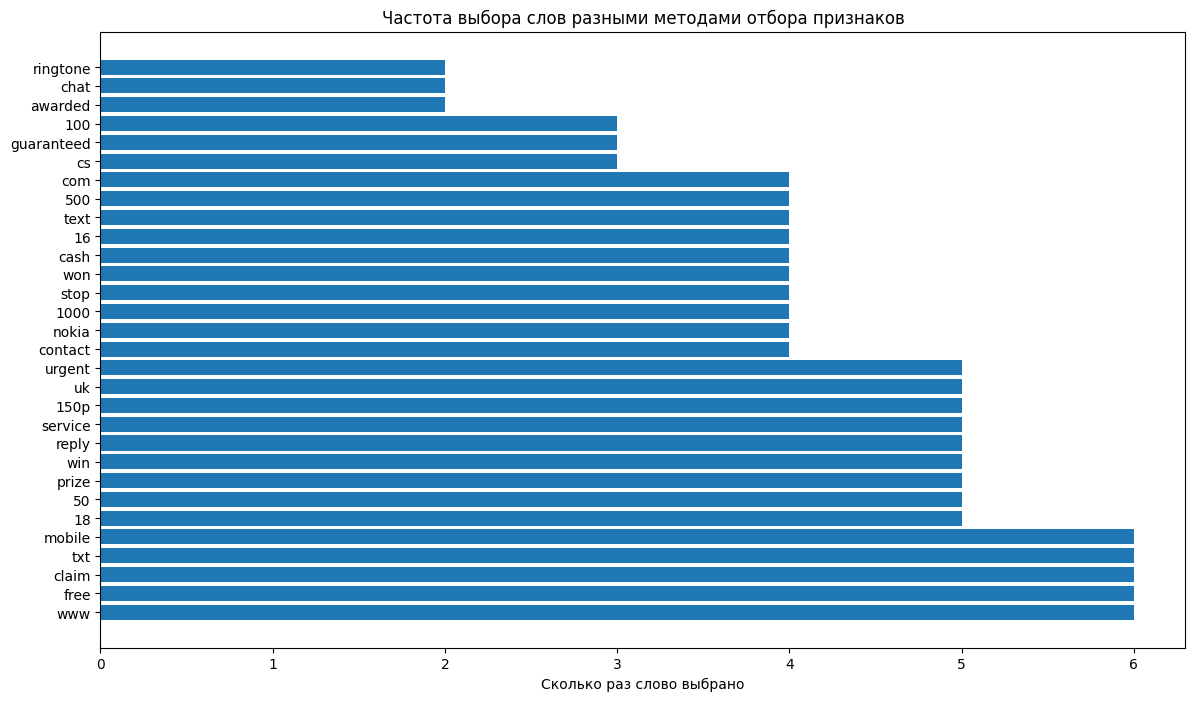

Всего уникальных слов: 72

Слова, выбранные всеми 6 методами:
txt
free
claim
www
mobile


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
all_results = [chi2_result, anova_result, rf_result, gd_result, rfe_result, rfecv_result]
word_counter = Counter()
for result in all_results:
    word_counter.update(result)

words = list(word_counter.keys())
fs = list(word_counter.values())
sorted_indices = np.argsort(fs)[::-1]
words_sorted = [words[i] for i in sorted_indices]
frequencies_sorted = [fs[i] for i in sorted_indices]

plt.figure(figsize=(14, 8))
bars = plt.barh(words_sorted[:30], frequencies_sorted[:30])
plt.xlabel('Сколько раз слово выбрано')
plt.title('Частота выбора слов разными методами отбора признаков')
plt.show()

print(f"Всего уникальных слов: {len(words)}\n")
print(f"Слова, выбранные всеми 6 методами:")
for word, freq in word_counter.items():
    if freq == 6:
        print(word)

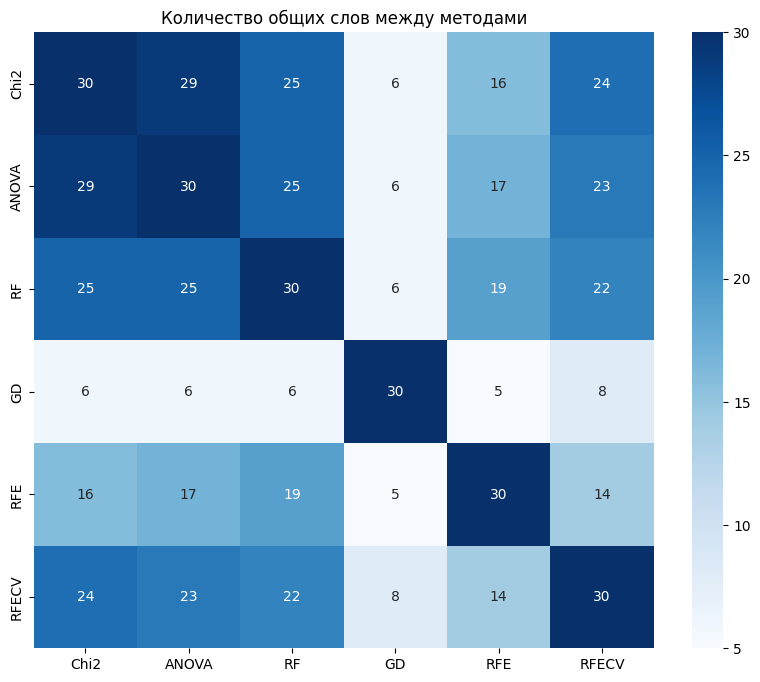

In [145]:
import pandas as pd
import seaborn as sns

methods = ['Chi2', 'ANOVA', 'RF', 'GD', 'RFE', 'RFECV']
intersection_matrix = pd.DataFrame(index=methods, columns=methods)

for i, name_i in enumerate(methods):
    for j, name_j in enumerate(methods):
        set_i = set(all_results[i])
        set_j = set(all_results[j])
        intersection_matrix.loc[name_i, name_j] = len(set_i & set_j)

plt.figure(figsize=(10, 8))
sns.heatmap(intersection_matrix.astype(int), annot=True, cmap='Blues')
plt.title('Количество общих слов между методами')
plt.show()

#### Обучение разных классификаторов

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

def three_classifiers(X_train, X_test, y_train, y_test):
    results = {}
    
    lr = LogisticRegression(max_iter=100, random_state=1633)
    lr.fit(X_train, y_train)
    results['LogisticRegression'] = f1_score(y_test, lr.predict(X_test))
    
    rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=1633)
    rf.fit(X_train, y_train)
    results['RandomForest'] = f1_score(y_test, rf.predict(X_test))
    
    dt = DecisionTreeClassifier(random_state=1633, max_depth=5)
    dt.fit(X_train, y_train)
    results['DecisionTree'] = f1_score(y_test, dt.predict(X_test))
    
    return results

In [188]:
def compare_feature_selection(X, y, feature_names, selected_features):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16, stratify=y)
    all_results = {}
    results_before = three_classifiers(X_train, X_test, y_train, y_test)
    all_results['before'] = results_before
    
    for method_name, selected_words in selected_features.items():
        selected_indices = []
        for word in selected_words:
                idx = np.where(feature_names == word)[0][0]
                selected_indices.append(idx)
        X_train_selected = X_train[:, selected_indices]
        X_test_selected = X_test[:, selected_indices]
        results_after = three_classifiers(X_train_selected, X_test_selected, y_train, y_test)
        all_results[method_name] = results_after
    
    return all_results, X_train, X_test, y_train, y_test

In [190]:
selector_results = {
    'Chi2': chi2_result,
    'Anova': anova_result,
    'L1 + L2': gd_result,
    'RF': rf_result,
    'RFE': rfe_result,
    'RFECV': rfecv_result
}

results, X_train_full, X_test_full, y_train, y_test = compare_feature_selection(X, y, feature_names, selector_results)

print("Сравнение качества классификаторов (F1-score):")

df_results = pd.DataFrame(results).T
df_results

Сравнение качества классификаторов (F1-score):


,LogisticRegression,RandomForest,DecisionTree
before,0.901099,0.880597,0.651982
Chi2,0.803030,0.818533,0.657895
Anova,0.816479,0.830769,0.657895
L1 + L2,0.739837,0.719368,0.717131
RF,0.801556,0.850746,0.657895
RFE,0.848708,0.876325,0.657895
RFECV,0.770428,0.845283,0.657895


In [193]:

best_method = df_results.drop('before').mean(axis=1).idxmax()
best_score = df_results.drop('before').mean(axis=1).max()

print(f"\nЛучший метод отбора признаков: {best_method}")
print(f"Средний F1-score по всем классификаторам: {best_score:.4f}")
print(f"Размерность до отбора: {X_train_full.shape[1]} признаков")
print(f"Размерность после отбора: 30 признаков")


Лучший метод отбора признаков: RFE
Средний F1-score по всем классификаторам: 0.7943
Размерность до отбора: 8444 признаков
Размерность после отбора: 30 признаков


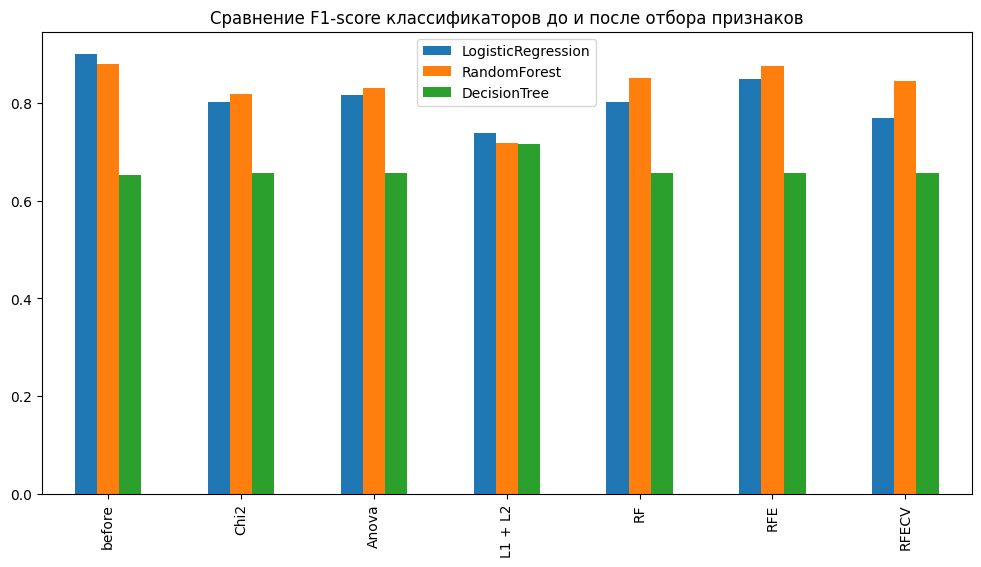

In [199]:
df_results.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение F1-score классификаторов до и после отбора признаков')
plt.show()

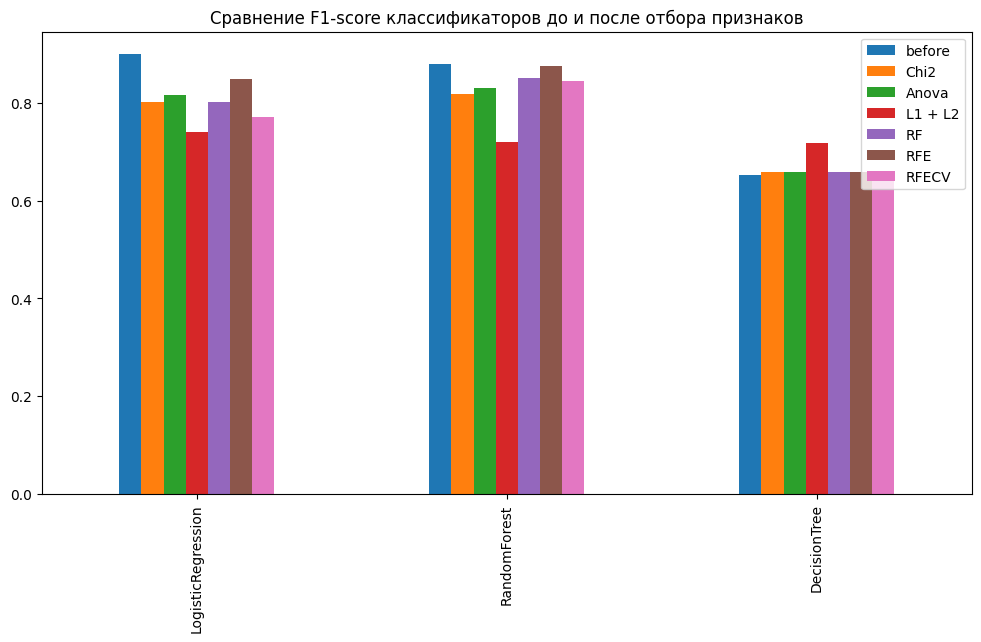

In [200]:
df_results.T.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение F1-score классификаторов до и после отбора признаков')
plt.show()

Выбранный способ отбора признаков - RFE.

### Кластеризация

#### k-means: алгоритм кластеризации

In [30]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

def k2_means(X, y_train, max_iter=100):
    np.random.seed(1633)
    X_dense = X.toarray()
    X_normalized = normalize(X_dense)
    n = X_dense.shape[0]
    
    indexes = np.random.choice(n, 2, replace=False)
    centroids = X_normalized[indexes].copy()
    
    for _ in range(max_iter):
        distances = cosine_distances(X_normalized, centroids)
        classes = np.argmin(distances, axis=1)
        
        if np.sum(classes == 0) == 0 or np.sum(classes == 1) == 0:
            indexes = np.random.choice(n, 2, replace=False)
            centroids = X_dense[indexes].copy()
            continue
        
        new_centroids = np.zeros_like(centroids)
        for i in range(2):
            cluster_points = X_dense[classes == i]
            new_centroids[i] = cluster_points.mean(axis=0)
        
        centroids = new_centroids

    return classes, centroids

In [209]:
X.shape

(5572, 8444)

In [207]:
from sklearn.metrics import classification_report, f1_score
y_pred, _ = k2_means(X, y, max_iter=100)

In [210]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y, y_pred))

0.8501435750179469


In [211]:
X_new = X[:, selected_indices_rfe]
X_new.shape

(5572, 30)

In [215]:
from sklearn.metrics import adjusted_rand_score, silhouette_score

classes, _ = k2_means(X, y, max_iter=100)
classes_new, _ = k2_means(X_new, y, max_iter=100)

In [216]:
print(f"ARI до отбора признаков: {adjusted_rand_score(y, classes):.4f}")
print(f"ARI после отбора признаков: {adjusted_rand_score(y, classes_new):.4f}")
print(f"Silhouette до отбора признаков: {silhouette_score(X.toarray(), classes):.4f}")
print(f"Silhouette после отбора признаков: {silhouette_score(X_new.toarray(), classes_new):.4f}")

ARI до отбора признаков: -0.0003
ARI после отбора признаков: 0.1142
Silhouette до отбора признаков: -0.1536
Silhouette после отбора признаков: 0.7382


### РСА и tSNE

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=1633, n_init=10)
clusters_new = kmeans.fit_predict(X_train)
centroids_new = kmeans.cluster_centers_

In [27]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def rca_tsne(X, y, clusters, title_prefix=""):
    X = X.toarray()
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X)
    
    _, axes = plt.subplots(2, 2, figsize=(10, 10))

    for i in range(2):
        axes[0, i].scatter(X_pca[:, 0], X_pca[:, 1], c=y if i == 0 else clusters, cmap='coolwarm' if i == 0 else 'viridis', alpha=0.6, s=20)
        axes[0, i].set_title(f'{title_prefix} PCA - {"Реальные классы" if i == 0 else "Кластеры K-Means"}')
        axes[0, i].set_xlabel('PC1')
        axes[0, i].set_ylabel('PC2')

        axes[1, i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y if i == 0 else clusters, cmap='coolwarm' if i == 0 else 'viridis', alpha=0.6, s=20)
        axes[1, i].set_title(f'{title_prefix} t-SNE - {"Реальные классы" if i == 0 else "Кластеры K-Means"}')
        axes[1, i].set_xlabel('t-SNE 1')
        axes[1, i].set_ylabel('t-SNE 2')
    
    plt.tight_layout()
    plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)
    plt.show()

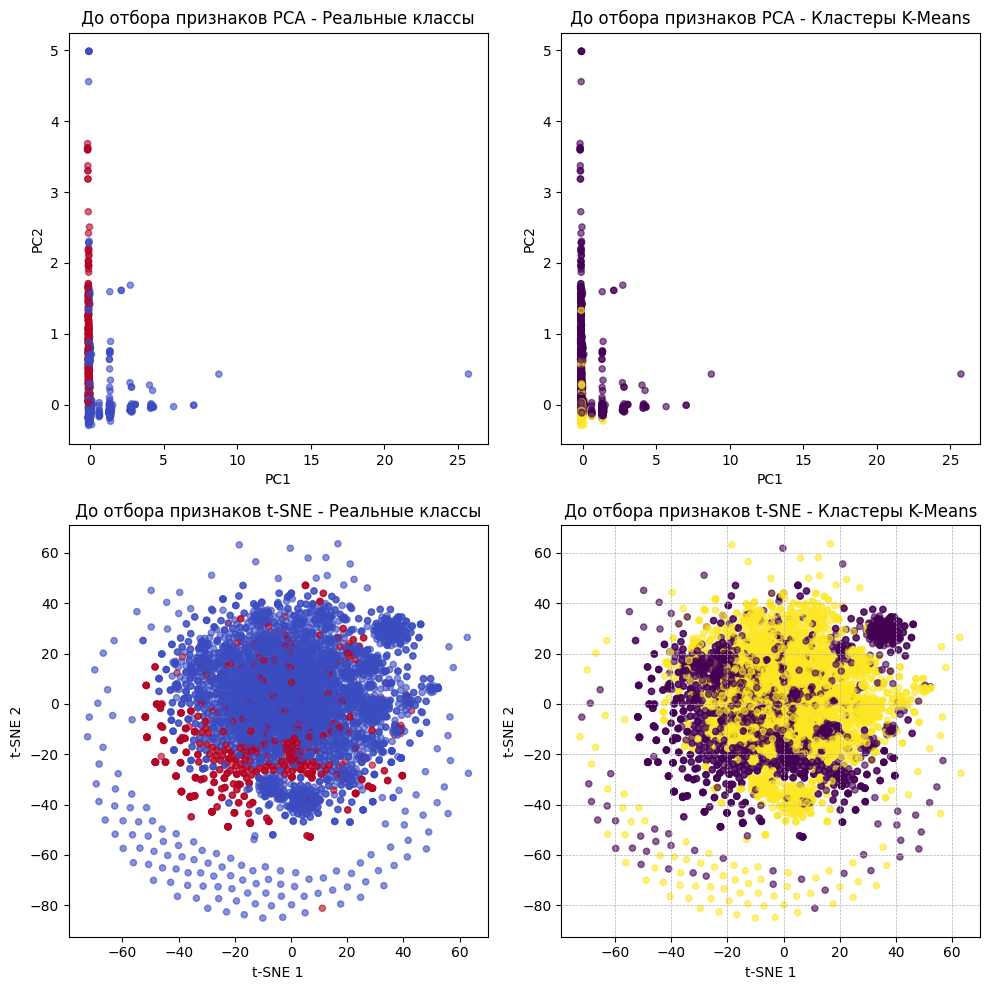

In [31]:
clusters_before, _ = k2_means(X, y)
rca_tsne(X, y, clusters_before, "До отбора признаков")

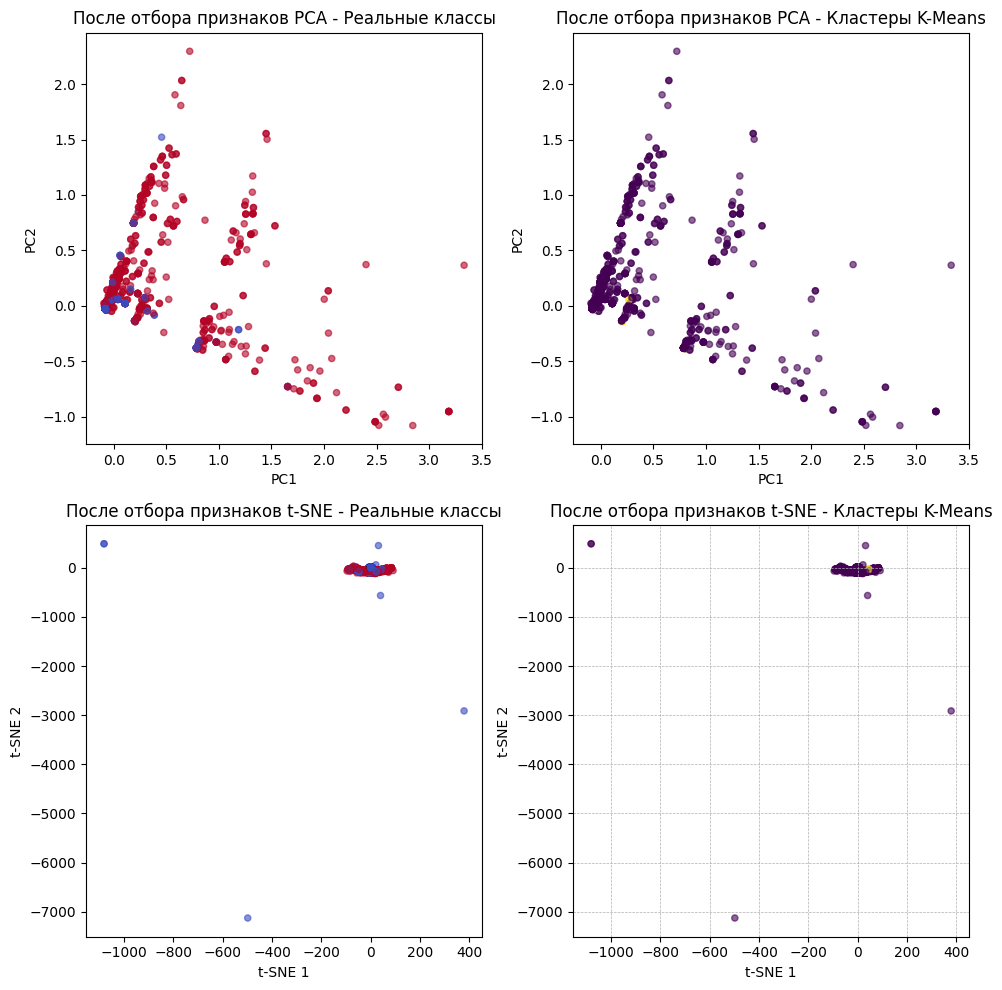

In [32]:
X_small = X[:, selected_indices_rfe]
clusters_after, _ = k2_means(X_small, y)
rca_tsne(X_small, y, clusters_after, "После отбора признаков")